Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
✅ Full model loaded successfully from /content/drive/MyDrive/Model/infosys_model_full.pth
🔎 Found 60 images. Starting predictions...


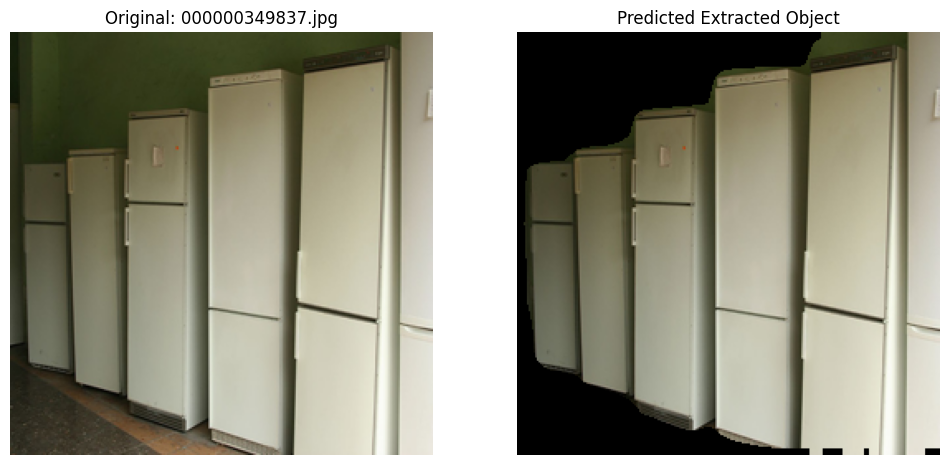

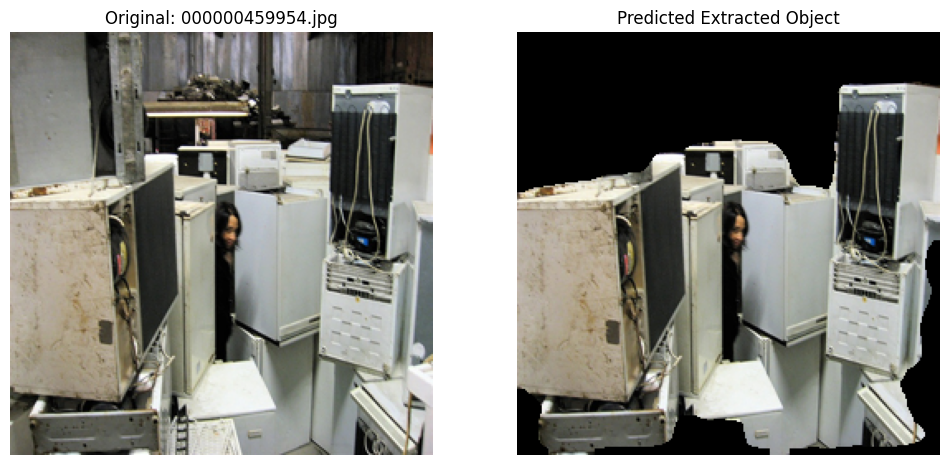

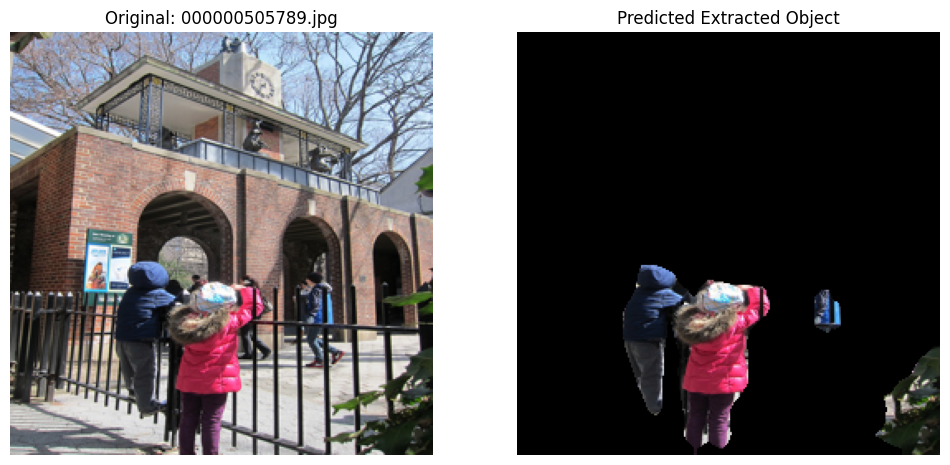

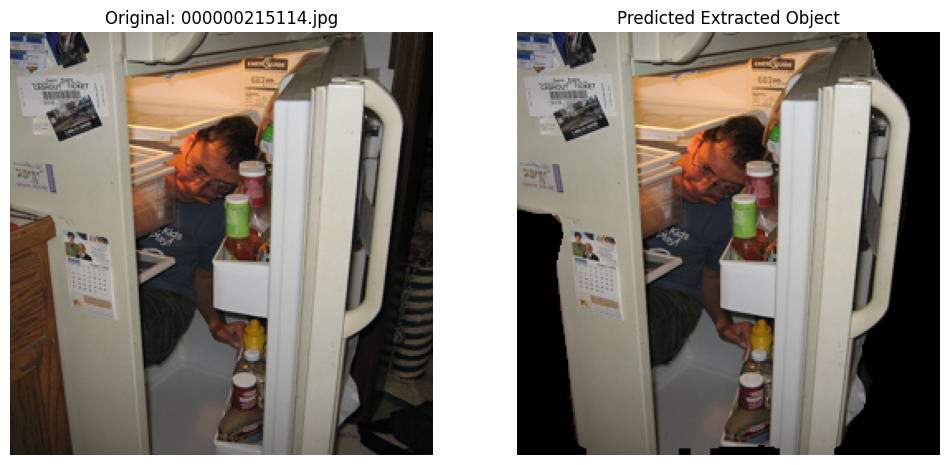

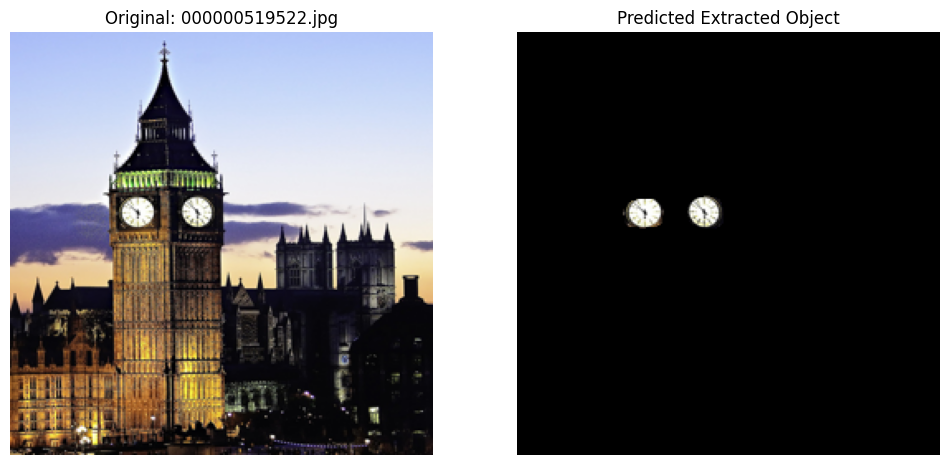

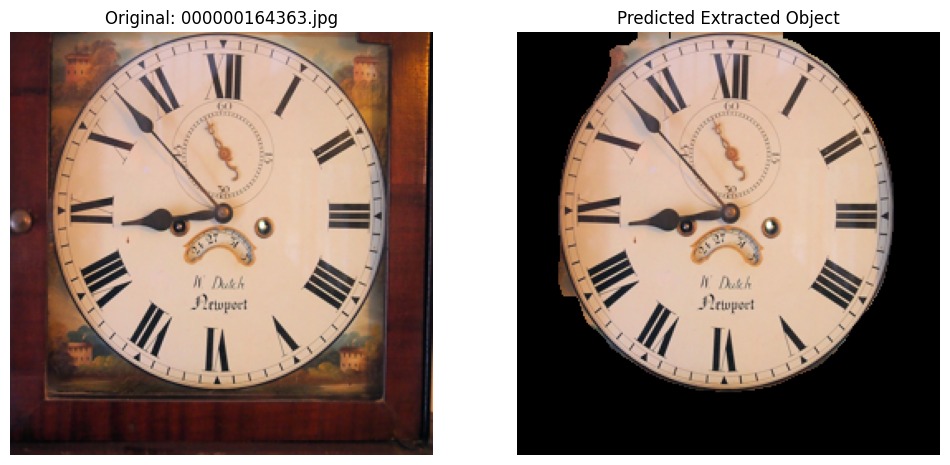

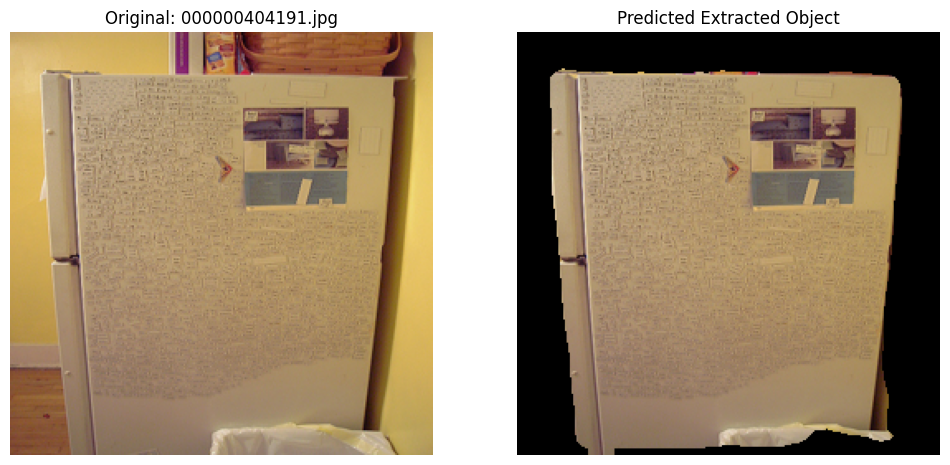

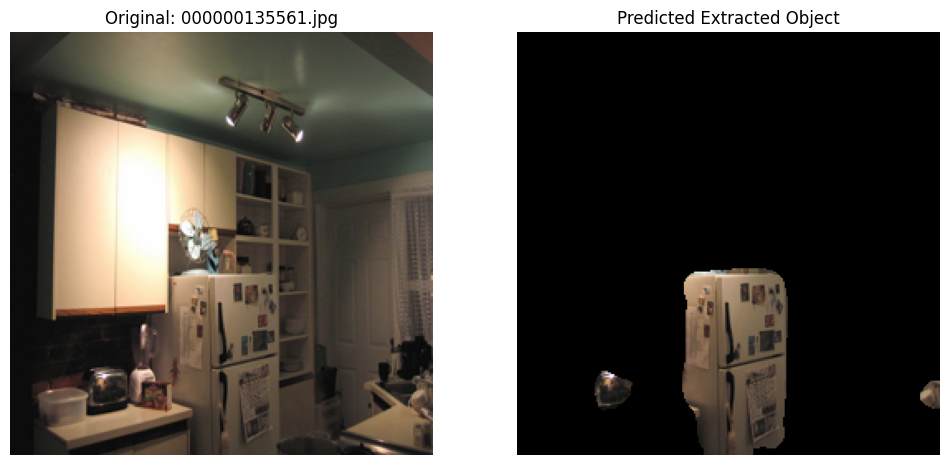

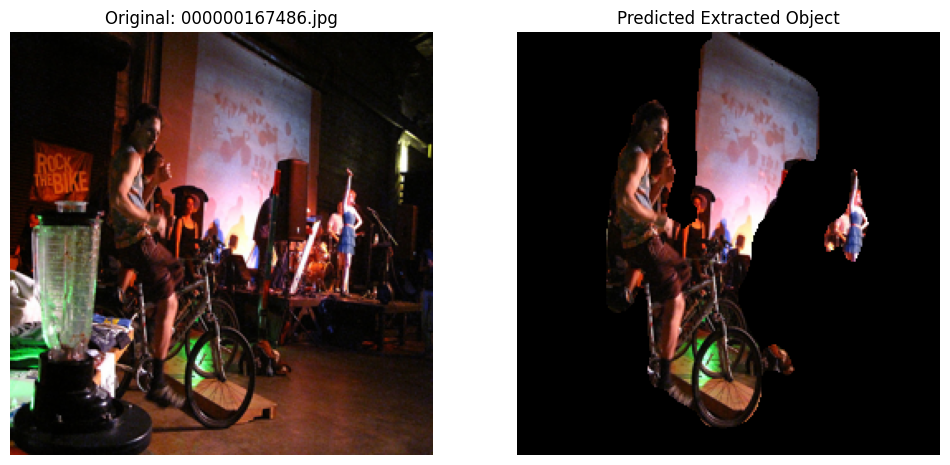

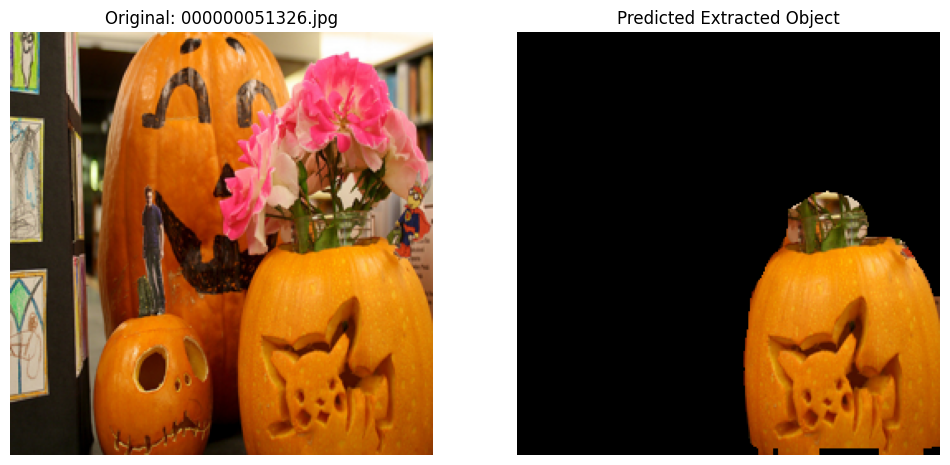

In [2]:
# =======================
# 1️⃣ Mount Google Drive
# =======================
from google.colab import drive
drive.mount('/content/drive')

# =======================
# 2️⃣ Imports
# =======================
import torch
import torchvision.transforms as T
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =======================
# 3️⃣ Load the full model
# =======================
# Add safe globals to allow DeepLabV3 class
from torchvision.models.segmentation import DeepLabV3
torch.serialization.add_safe_globals([DeepLabV3])

# Path to your full model
full_model_path = "/content/drive/MyDrive/Model/infosys_model_full.pth"

# Load the model
model = torch.load(full_model_path, weights_only=False)
model.to(device)
model.eval()
print(f"✅ Full model loaded successfully from {full_model_path}")

# =======================
# 4️⃣ Helper function: extract object with black background
# =======================
def extract_object_rgb(image_np, mask_np):
    obj = np.zeros_like(image_np, dtype=np.uint8)  # black background
    obj[mask_np > 0] = image_np[mask_np > 0]
    return obj

# =======================
# 5️⃣ Preprocessing transform
# =======================
transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor()
])

# =======================
# 6️⃣ Test images folder
# =======================
test_folder = "/content/drive/MyDrive/testImages"
image_files = [f for f in os.listdir(test_folder) if f.lower().endswith((".jpg", ".jpeg", ".png"))]

if not image_files:
    print("❌ No images found in testimages folder!")
else:
    print(f"🔎 Found {len(image_files)} images. Starting predictions...")

num_images_to_show = 10  # change this number to control how many to visualize

for img_file in image_files[:num_images_to_show]:  # slice the list
    img_path = os.path.join(test_folder, img_file)
    img_pil = Image.open(img_path).convert("RGB")
    orig_np = np.array(img_pil.resize((256, 256)))  # keep original for visualization

    # Apply transform
    input_tensor = transform(img_pil).unsqueeze(0).to(device)

    # Predict mask
    with torch.no_grad():
        output = model(input_tensor)['out']
        pred_mask = output.argmax(1).squeeze(0).cpu().numpy()

    # Extract object with black background
    pred_obj = extract_object_rgb(orig_np, pred_mask)

    # Show results
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].imshow(orig_np)
    axs[0].set_title(f"Original: {img_file}")
    axs[0].axis("off")

    axs[1].imshow(pred_obj)
    axs[1].set_title("Predicted Extracted Object")
    axs[1].axis("off")

    plt.show()
